# TFM — Modelado Predictivo de la Severidad de Siniestros Viales en Guatemala

**Autor:** Carlos Alberto Calderón Illescas
**Máster en Big Data, Data Science e Inteligencia Artificial — Universidad Complutense de Madrid**

Notebook completo del trabajo: descarga de datos, ETL, análisis exploratorio, ingeniería de
características, modelado, evaluación fuera de tiempo, interpretabilidad y exportación de
artefactos. Se ejecuta de principio a fin sin intervención manual.

| Sección | Contenido |
|:--:|---|
| **0** | Descarga y verificación de los datos de origen (INE) |
| **1** | Carga y unificación de fuentes crudas (ETL INE/PNC 2018–2024) |
| **2** | Limpieza y control de calidad de datos |
| **3** | Partición temporal (2018–2023 vs. holdout Out-of-Time 2024) |
| **4** | Análisis exploratorio de datos (EDA) |
| **5** | Ingeniería de características |
| **6** | Modelado, validación cruzada y ajuste de hiperparámetros |
| **7** | Evaluación final sobre el holdout Out-of-Time 2024 |
| **8** | Interpretabilidad (SHAP) y prueba de robustez |
| **9** | Exportación de artefactos para la app de despliegue |

> **Disciplina Out-of-Time.** El año 2024 se aísla en la sección 3 y no participa en ninguna
> decisión de modelado: ni en el EDA, ni en la selección de variables, ni en el ajuste de
> hiperparámetros. Se usa una única vez, en la sección 7, para simular el desempeño del modelo
> ante datos de producción real.

In [ ]:
# --- Bootstrap de rutas ---------------------------------------------------------------
# Este notebook vive en notebooks/, pero todas las rutas relativas del analisis
# (data/raw/, modelo/, figuras/) estan escritas desde la RAIZ del repositorio.
# Esta celda situa el directorio de trabajo en esa raiz, de modo que el notebook funciona
# igual si se abre desde notebooks/ o si lo ejecuta src/reentrenar_modelo.py desde la raiz.
import os
from pathlib import Path

RAIZ_REPO = Path.cwd()
if RAIZ_REPO.name == "notebooks":
    RAIZ_REPO = RAIZ_REPO.parent
os.chdir(RAIZ_REPO)
print(f"Directorio de trabajo: {RAIZ_REPO}")


In [2]:
import os
import re
import glob
import json
import warnings
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)
from scipy.stats import chi2_contingency

# XGBoost y LightGBM son dependencias opcionales: la celda detecta cuales estan instaladas y
# la seccion 6 adapta la comparativa en consecuencia, de modo que la secuencia completa de ETL,
# EDA y modelado base se ejecuta aunque falte alguna. Versiones usadas: ver requirements.txt.
try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIBLE = True
except ImportError:
    XGBOOST_DISPONIBLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_DISPONIBLE = True
except ImportError:
    LIGHTGBM_DISPONIBLE = False

# Optuna se usa solo en la Seccion 6.2 (busqueda bayesiana de hiperparametros, quinta
# verificacion de robustez). Si no esta instalado, esa seccion se omite sin romper el notebook.
try:
    import optuna
    from optuna.samplers import TPESampler
    OPTUNA_DISPONIBLE = True
except ImportError:
    OPTUNA_DISPONIBLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

## 0. Descarga y verificación de los datos de origen

Los microdatos provienen del portal de datos abiertos del INE, que publica un archivo `.xlsx` por
año más el diccionario oficial de variables:
[datos.ine.gob.gt — Accidentes de tránsito, fallecidos y lesionados](https://datos.ine.gob.gt/en/dataset/accidentes-de-transito-fallecidos-y-lesionados)

Para que el trabajo sea reproducible sin descargas manuales, el script `src/descargar_datos.py`
(Anexo E) obtiene esos archivos de forma automática: consulta la API CKAN del portal para
localizar las URLs vigentes de cada recurso y, si la API no responde, recurre a una lista de URLs
de respaldo verificadas manualmente.

> **Verificación de equivalencia (30 de agosto de 2026).** Se ejecutó `descargar_datos.py` contra
> el portal real y se compararon los 8 archivos obtenidos por la vía automática contra los que se
> habían descargado a mano al inicio del trabajo: **los 8 resultaron idénticos byte a byte
> (SHA-256)**. La automatización reproduce exactamente el dataset con el que se entrenó el modelo,
> lo que hace el pipeline reproducible de punta a punta desde la fuente oficial.

La celda siguiente verifica qué archivos están presentes y solo descarga los que falten: ejecutarla
repetidamente no vuelve a bajar nada ni altera los datos existentes.

In [4]:
# Verificacion de los archivos de origen. Si ya estan presentes, no se descarga nada.
# La descarga automatica esta implementada en src/descargar_datos.py (Anexo E, Cap. 6.4 de la memoria).
URL_PORTAL_INE = "https://datos.ine.gob.gt/en/dataset/accidentes-de-transito-fallecidos-y-lesionados"
CARPETA_DATOS_ORIGEN = "./data/raw/"
ANIOS_ESPERADOS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

os.makedirs(CARPETA_DATOS_ORIGEN, exist_ok=True)
presentes = sorted(glob.glob(os.path.join(CARPETA_DATOS_ORIGEN, "*.xlsx")))

print(f"Carpeta de datos de origen : {CARPETA_DATOS_ORIGEN}")
print(f"Archivos .xlsx encontrados : {len(presentes)}")
for ruta in presentes:
    print(f"    {os.path.basename(ruta):<52}{os.path.getsize(ruta)/1024:>9,.0f} KB")

faltantes = [a for a in ANIOS_ESPERADOS
             if not any(str(a) in os.path.basename(r) for r in presentes)]

if not faltantes:
    print(f"\nOK: los {len(ANIOS_ESPERADOS)} anios esperados (2018-2024) estan disponibles localmente.")
    print("    No se descarga nada.")
    print("    Para bajar una copia fresca del portal y compararla contra esta:")
    print("        python src/descargar_datos.py --carpeta ./data/verificacion/")
else:
    print(f"\nFaltan datos de: {faltantes}. Intentando la descarga automatica...")
    try:
        from descargar_datos import descargar_todos
        descargar_todos(carpeta=CARPETA_DATOS_ORIGEN)
        print("Descarga completada.")
    except Exception as e:
        print(f"No se pudo completar la descarga automatica ({type(e).__name__}: {e}).")
        print(f"Descarga manual desde: {URL_PORTAL_INE}")

Carpeta de datos de origen : ./data_cruda_ine/
Archivos .xlsx encontrados : 7
    base-de-datos-fallecidos-y-lesionados-pnc-2024.xlsx     1,152 KB
    fallecidos-y-lesionados-2023-pnc.xlsx                   1,143 KB
    fallecidos-y-lesionados-ano-2018.xlsx                   1,001 KB
    fallecidos-y-lesionados-ano-2019.xlsx                   1,132 KB
    fallecidos-y-lesionados-ano-2020.xlsx                     869 KB
    fallecidos-y-lesionados-ano-2021.xlsx                   1,167 KB
    fallecidos-y-lesionados-ano-2022.xlsx                   1,145 KB

OK: los 7 anios esperados (2018-2024) estan disponibles localmente.
    No se descarga nada.
    Para bajar una copia fresca del portal y compararla contra esta:
        python descargar_datos.py --carpeta ./data_cruda_verificacion/


## 1. Carga y unificación de fuentes crudas (ETL INE/PNC 2018–2024)

Se homogeneízan los esquemas de columnas de los 7 archivos anuales publicados por el INE
(a partir de los partes de la PNC) y se consolidan en un único dataset maestro.
El mapa de columnas está basado en el diccionario oficial de variables del INE.


In [6]:
CARPETA_DATOS = "./data/raw/"

# Mapa de columnas -> nombres estándar, basado en el diccionario oficial del INE
MAPA_COLUMNAS_INE = {
    'núm_corre': 'num_correlativo', 'NUM_CORRE': 'num_correlativo', 'CORRELATIVO': 'num_correlativo',
    'año_ocu': 'anio', 'AÑO_OCU': 'anio', 'ANIO_OCU': 'anio', 'AÑO': 'anio',
    'mes_ocu': 'mes', 'MES_OCU': 'mes', 'MES': 'mes',
    'día_ocu': 'dia', 'DÍA_OCU': 'dia', 'DIA_OCU': 'dia',
    'día_sem_ocu': 'dia_semana', 'DÍA_SEM_OCU': 'dia_semana', 'DIA_SEM_OCU': 'dia_semana',
    'hora_ocu': 'hora', 'HORA_OCU': 'hora',
    'depto_ocu': 'departamento', 'DEPTO_OCU': 'departamento', 'DEPTO': 'departamento',
    'mupio_ocu': 'municipio', 'MUPIO_OCU': 'municipio', 'MUNICIPIO': 'municipio',
    'zona_ocu': 'zona', 'ZONA_OCU': 'zona',
    'sexo_per': 'sexo', 'SEXO_PER': 'sexo', 'SEXO': 'sexo',
    'edad_per': 'edad', 'EDAD_PER': 'edad', 'EDAD': 'edad',
    'tipo_veh': 'tipo_vehiculo', 'TIPO_VEH': 'tipo_vehiculo',
    'marca_veh': 'marca_vehiculo', 'MARCA_VEH': 'marca_vehiculo',
    'color_veh': 'color_vehiculo', 'COLOR_VEH': 'color_vehiculo',
    'tipo_eve': 'tipo_evento', 'TIPO_EVE': 'tipo_evento',
    'fall_les': 'severidad', 'FALL_LES': 'severidad', 'GRAVEDAD': 'severidad',
    'int_o_noint': 'hospitalizado', 'INT_O_NOINT': 'hospitalizado',
}

# Diccionario oficial de codigos INE, cargado directamente del archivo (no transcrito a mano,
# para eliminar el riesgo de errores de transcripcion en variables de muchas categorias como municipio).
def cargar_diccionario_ine(ruta_archivo):
    """Lee diccionario-fallecidos-y-lesionados.xlsx y devuelve {variable: {codigo: etiqueta}}."""
    tabla = pd.read_excel(ruta_archivo, header=2)
    tabla = tabla[["Variable", "Etiqueta", "Código", "Valor"]]
    tabla.columns = ["variable", "etiqueta", "codigo", "valor"]
    tabla["variable"] = tabla["variable"].ffill()
    diccionario = {}
    for variable, grupo in tabla.groupby("variable"):
        mapa = {}
        for codigo, valor in zip(grupo["codigo"], grupo["valor"]):
            try:
                mapa[int(codigo)] = str(valor).strip()
            except (ValueError, TypeError):
                pass
        if mapa:
            diccionario[variable] = mapa
    return diccionario

DICCIONARIO_INE = cargar_diccionario_ine("./data/diccionario-fallecidos-y-lesionados.xlsx")
MAPA_DEPARTAMENTO = DICCIONARIO_INE["depto_ocu"]
MAPA_MUNICIPIO = DICCIONARIO_INE["mupio_ocu"]
MAPA_TIPO_VEHICULO = DICCIONARIO_INE["tipo_veh"]
MAPA_TIPO_EVENTO = DICCIONARIO_INE["tipo_eve"]
MAPA_SEXO = DICCIONARIO_INE["sexo_per"]
MAPA_MARCA = DICCIONARIO_INE.get("marca_veh", {})
MAPA_DIA_SEMANA = {1: "Lunes", 2: "Martes", 3: "Miercoles", 4: "Jueves", 5: "Viernes", 6: "Sabado", 7: "Domingo"}

# El diccionario dice que "Ignorado" en severidad es codigo 3, pero los datos reales usan 9
# (verificado en la auditoria de la seccion 2) -- se define a mano por esa discrepancia documentada.
MAPA_SEVERIDAD = {1: "Fallecido", 2: "Lesionado", 9: "Ignorado"}

# Vehiculos considerados "vulnerables" por carecer de estructura de proteccion (Cap. 3.2 de la memoria)
VEHICULOS_VULNERABLES = {4, 14, 18, 22}  # Motocicleta, Moto taxi, Bicicleta, Cuatrimoto

COLUMNAS_FINALES = ["anio", "mes", "dia", "dia_semana", "hora", "departamento", "municipio", "zona",
                    "sexo", "edad", "tipo_vehiculo", "marca_vehiculo", "color_vehiculo",
                    "tipo_evento", "severidad", "hospitalizado"]


def procesar_archivo_ine(ruta_archivo):
    """Lee un archivo anual del INE/PNC y lo homogeneiza al esquema estandar."""
    nombre = os.path.basename(ruta_archivo)
    print(f"Cargando: {nombre}")
    df = pd.read_excel(ruta_archivo)
    df.columns = df.columns.str.strip()
    df = df.rename(columns=MAPA_COLUMNAS_INE)
    df.columns = df.columns.str.lower()

    if "anio" not in df.columns:
        match = re.search(r"20\d{2}", nombre)
        if match:
            df["anio"] = int(match.group(0))

    if "marca_vehiculo" in df.columns and MAPA_MARCA:
        # El diccionario del INE trae la marca como codigo numerico; se traduce a texto legible
        # aqui mismo (igual que departamento/municipio/tipo_vehiculo), en vez de dejarla como
        # codigo crudo -- afecta solo la legibilidad de EDA/reportes, no el modelo (que ya
        # codifica marca_vehiculo por frecuencia, sin importar si la etiqueta es texto o numero).
        df["marca_vehiculo"] = df["marca_vehiculo"].map(MAPA_MARCA).fillna(df["marca_vehiculo"])

    columnas_presentes = [c for c in COLUMNAS_FINALES if c in df.columns]
    return df[columnas_presentes]


archivos = sorted(glob.glob(os.path.join(CARPETA_DATOS, "*.xlsx")))
df_maestro = pd.concat([procesar_archivo_ine(f) for f in archivos], ignore_index=True)

print(f"\nTotal de registros unificados (2018-2024): {len(df_maestro):,}")
print(df_maestro["anio"].value_counts().sort_index())


Cargando: base-de-datos-fallecidos-y-lesionados-pnc-2024.xlsx
Cargando: fallecidos-y-lesionados-2023-pnc.xlsx
Cargando: fallecidos-y-lesionados-ano-2018.xlsx
Cargando: fallecidos-y-lesionados-ano-2019.xlsx
Cargando: fallecidos-y-lesionados-ano-2020.xlsx
Cargando: fallecidos-y-lesionados-ano-2021.xlsx
Cargando: fallecidos-y-lesionados-ano-2022.xlsx

Total de registros unificados (2018-2024): 71,951
anio
3           1
2018     9406
2019    10664
2020     8142
2021    10544
2022    10722
2023    11198
2024    11274
Name: count, dtype: int64


## 2. Limpieza y control de calidad de datos

Antes de decidir qué depurar, se audita sistemáticamente cada variable clave contra su rango
lógico (según el diccionario oficial del INE), en vez de corregir solo lo que salta a la vista.


In [8]:
# Auditoria de calidad: valores presentes pero fuera de rango logico (codigos "Ignorado")
rangos_validos = {"hora": (0, 23), "edad": (0, 100), "mes": (1, 12), "dia": (1, 31), "dia_semana": (1, 7)}
print("=== AUDITORIA DE CALIDAD DE DATOS ===")
for col, (lo, hi) in rangos_validos.items():
    nulos = df_maestro[col].isna().sum()
    invalidos = ((~df_maestro[col].between(lo, hi)) & df_maestro[col].notna()).sum()
    print(f"{col:12s} | nulos: {nulos:6,} ({nulos/len(df_maestro)*100:5.2f}%) | "
          f"presentes-pero-invalidos: {invalidos:6,} ({invalidos/len(df_maestro)*100:5.2f}%)")


=== AUDITORIA DE CALIDAD DE DATOS ===
hora         | nulos:      0 ( 0.00%) | presentes-pero-invalidos:     39 ( 0.05%)
edad         | nulos:      0 ( 0.00%) | presentes-pero-invalidos:  6,947 ( 9.66%)
mes          | nulos:      0 ( 0.00%) | presentes-pero-invalidos:      0 ( 0.00%)
dia          | nulos: 22,472 (31.23%) | presentes-pero-invalidos:      0 ( 0.00%)
dia_semana   | nulos: 22,472 (31.23%) | presentes-pero-invalidos:      0 ( 0.00%)


Con la auditoría hecha, las reglas de depuración quedan justificadas (no arbitrarias):

- **Años inválidos:** 1 registro con `anio = 3` en el archivo de 2018 (error de captura del dato
  oficial, confirmado al revisar el Excel original). Se descarta por no ser un año real.
- **Severidad no clasificada:** los registros con `severidad = 9` ("Ignorado") se descartan porque
  no aportan señal a un problema de clasificación binaria.
- **Edad = 999 ("Ignorado", 9.7% de los registros):** se trata como dato faltante y se imputa
  más adelante (mediana), en vez de descartar el registro completo.
- **Hora = 99 ("Ignorado", 0.05%):** mismo tratamiento — a NaN. Es un volumen pequeño, pero al no
  filtrarlo se rompía tanto el gráfico de tasa por hora (sección 4.2) como el propio modelo, que
  interpretaba 99 como una hora real. Se detectó precisamente por esa distorsión visual.
- **Día de la semana faltante (31.2%):** es un vacío estructural real de la fuente (no un error
  puntual). En vez de asumir silenciosamente "no es fin de semana" cuando falta el dato, se
  conserva como categoría explícita "Desconocido" en `es_fin_de_semana` (sección 5).
- **Sexo = 9 ("Ignorado", 0.3%):** se conserva como categoría propia — es una variable categórica,
  así que "Ignorado" es una categoría más, no rompe ningún cálculo numérico.


In [10]:
filas_originales = len(df_maestro)

# Años válidos
df = df_maestro[df_maestro["anio"].between(2018, 2024)].copy()

# Severidad valida (1: Fallecido, 2: Lesionado); se descarta 9 (Ignorado)
df = df[df["severidad"].isin([1, 2])].copy()
df["severidad_label"] = df["severidad"].map(MAPA_SEVERIDAD)
df["target"] = (df["severidad"] == 1).astype(int)

# Codigos "Ignorado" en variables numericas -> NaN (se imputan mas adelante en el pipeline)
df.loc[(df["edad"] < 0) | (df["edad"] > 100), "edad"] = np.nan
df.loc[~df["hora"].between(0, 23), "hora"] = np.nan

print(f"Filas originales:        {filas_originales:,}")
print(f"Filas tras depuracion:   {len(df):,}  ({filas_originales - len(df)} descartadas)")
print(f"\nBalance de clases (2018-2024): {df['target'].value_counts(normalize=True).round(4).to_dict()}")


Filas originales:        71,951
Filas tras depuracion:   71,941  (10 descartadas)

Balance de clases (2018-2024): {0: 0.809, 1: 0.191}


## 3. Partición temporal (evita *data leakage* de futuro)

Siguiendo la estrategia *Out-of-Time* ya definida en la memoria: el año 2024 se aparta por completo
como muestra de simulación de producción, y **no se toca hasta la evaluación final** (sección 7).
Todo el EDA, feature engineering, validación cruzada y ajuste de hiperparámetros ocurre solo sobre 2018–2023.


In [12]:
df_eda = df[df["anio"] <= 2023].copy()
df_oot = df[df["anio"] == 2024].copy()

print(f"Train / EDA (2018-2023): {len(df_eda):,} registros | Fallecidos: {df_eda['target'].mean()*100:.2f}%")
print(f"Out-of-Time (2024):      {len(df_oot):,} registros | Fallecidos: {df_oot['target'].mean()*100:.2f}%")


Train / EDA (2018-2023): 60,669 registros | Fallecidos: 18.75%
Out-of-Time (2024):      11,272 registros | Fallecidos: 20.98%


## 4. Análisis exploratorio de datos (EDA)

Replica los hallazgos centrales de la memoria (Cap. 3): desbalance de clases, patrón horario
y concentración geográfica de la letalidad. Todo se calcula únicamente sobre 2018–2023.


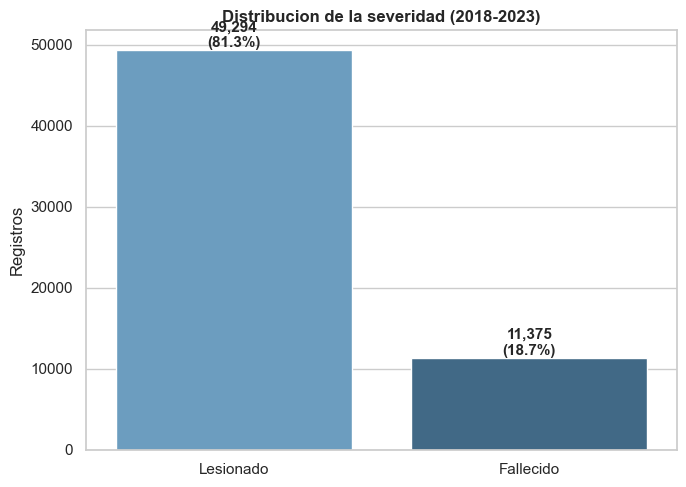

In [14]:
# 4.1 Distribucion de la variable objetivo
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_eda, x="severidad_label", hue="severidad_label",
                    order=df_eda["severidad_label"].value_counts().index,
                    palette="Blues_d", legend=False)
total = len(df_eda)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{int(p.get_height()):,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.title("Distribucion de la severidad (2018-2023)", fontweight="bold")
plt.xlabel("")
plt.ylabel("Registros")
plt.tight_layout()
plt.savefig("figuras/01_distribucion_target.png", dpi=150)
plt.show()


**Lectura.** El desbalance es marcado: alrededor de 4 de cada 5 personas involucradas resultan
lesionadas y 1 de cada 5 fallece. Esto condiciona dos decisiones posteriores: la sección 6 pondera
las clases (`sample_weight`) en vez de entrenar sobre los datos crudos, y las métricas reportadas
incluyen PR-AUC junto al ROC-AUC — sobre una clase minoritaria, la exactitud (*accuracy*) sería una
métrica engañosa.

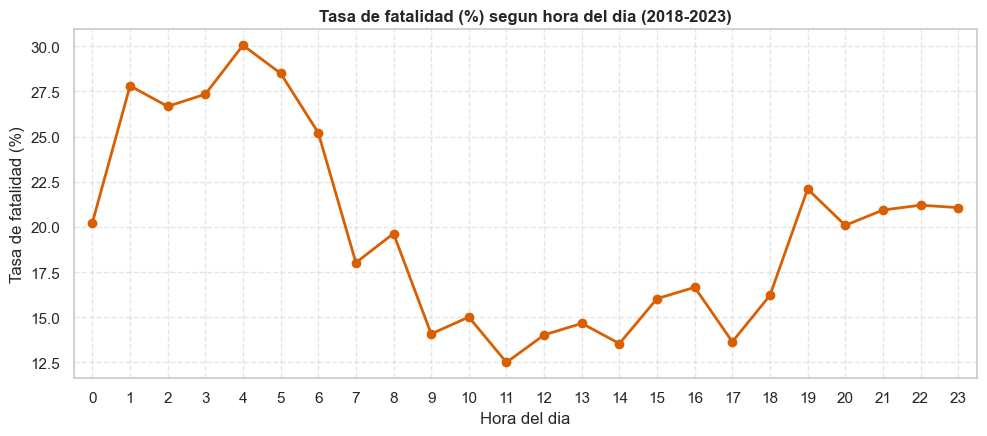

In [16]:
# 4.2 Tasa de mortalidad por hora del dia
# Nota: la hora=99 ("Ignorado") ya se convirtio a NaN en la seccion 2 -- de no hacerlo,
# ese punto aparece muy lejos en el eje X y distorsiona por completo la lectura del grafico.
tasa_hora = df_eda.dropna(subset=["hora"]).groupby("hora")["target"].mean() * 100
tasa_hora.index = tasa_hora.index.astype(int)

plt.figure(figsize=(10, 4.5))
plt.plot(tasa_hora.index, tasa_hora.values, marker="o", color="#d95f02", linewidth=2)
plt.title("Tasa de fatalidad (%) segun hora del dia (2018-2023)", fontweight="bold")
plt.xlabel("Hora del dia")
plt.ylabel("Tasa de fatalidad (%)")
plt.xlim(-0.5, 23.5)
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figuras/02_tasa_mortalidad_hora.png", dpi=150)
plt.show()


**Lectura.** La tasa de fatalidad no es pareja a lo largo del día: alcanza su máximo alrededor de
las 4:00 (~30%), se mantiene alta durante la madrugada, cae a su mínimo cerca del mediodía (~13%)
y repunta moderadamente por la noche. La hipótesis de trabajo es la menor visibilidad y el menor
auxilio inmediato disponible de madrugada. Este patrón cíclico —y no lineal— es justamente lo que
justifica la codificación seno/coseno de la hora en la sección 5.

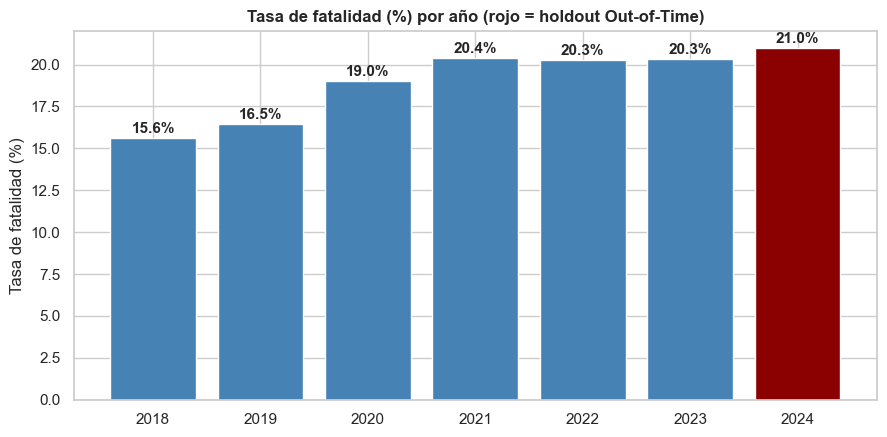

In [18]:
# 4.3 Tendencia anual de la tasa de fatalidad (2018-2024, incluye el año Out-of-Time)
tasa_anual = df.groupby("anio")["target"].mean() * 100

plt.figure(figsize=(9, 4.5))
colores = ["steelblue"] * (len(tasa_anual) - 1) + ["darkred"]  # 2024 resaltado (es el holdout)
plt.bar(tasa_anual.index.astype(str), tasa_anual.values, color=colores)
for i, v in enumerate(tasa_anual.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
plt.title("Tasa de fatalidad (%) por año (rojo = holdout Out-of-Time)", fontweight="bold")
plt.ylabel("Tasa de fatalidad (%)")
plt.tight_layout()
plt.savefig("figuras/07_tendencia_anual.png", dpi=150)
plt.show()

**Lectura de este gráfico:** 2024 (en rojo) muestra una tasa de fatalidad de ~21%, la más alta
de toda la serie 2018–2024, por encima del ~18.75% observado en 2018–2023. Es una señal real de
que la siniestralidad grave viene subiendo, y explica en parte por qué el modelo —entrenado
únicamente con el patrón histórico de 2018–2023— pierde algo de precisión al evaluarse sobre 2024:
son datos genuinamente distintos, no solo una partición al azar.

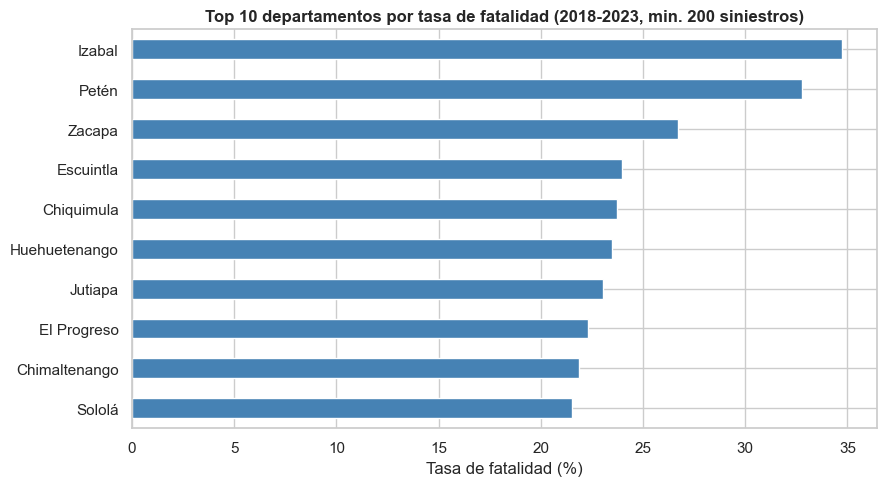

In [20]:
# 4.4 Top 10 departamentos por tasa de fatalidad (con volumen minimo para evitar ruido estadistico)
resumen_depto = df_eda.groupby("departamento")["target"].agg(["mean", "count"])
resumen_depto = resumen_depto[resumen_depto["count"] >= 200]
top10 = (resumen_depto["mean"] * 100).sort_values(ascending=False).head(10)
top10.index = [MAPA_DEPARTAMENTO.get(c, c) for c in top10.index]

plt.figure(figsize=(9, 5))
top10.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 departamentos por tasa de fatalidad (2018-2023, min. 200 siniestros)", fontweight="bold")
plt.xlabel("Tasa de fatalidad (%)")
plt.tight_layout()
plt.savefig("figuras/03_top10_departamentos.png", dpi=150)
plt.show()

**Lectura.** El departamento de Guatemala concentra el mayor volumen absoluto de siniestros pero
registra la tasa de fatalidad **más baja** del país (~13%). En el extremo opuesto, Petén, Izabal y
Zacapa —corredores de carretera de alta velocidad y menor cobertura hospitalaria— casi triplican
esa tasa. El filtro de volumen mínimo (200 siniestros) evita que un departamento con pocos casos
encabece el ranking por azar estadístico.

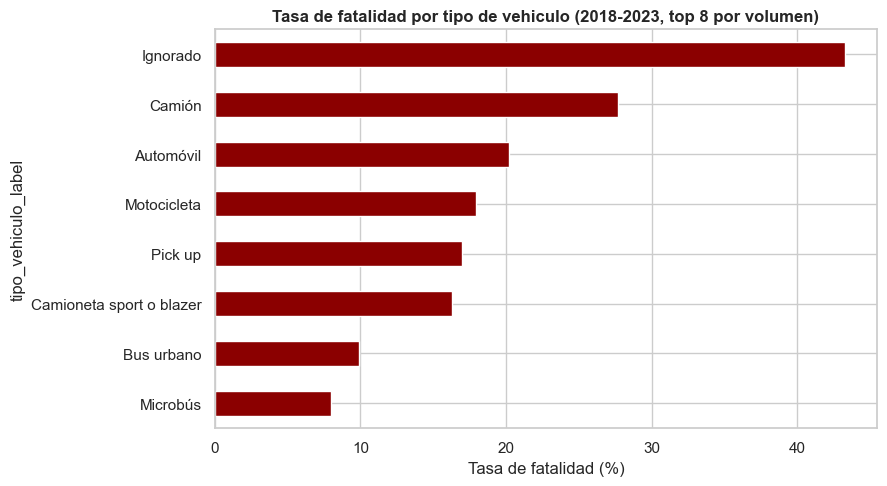

In [22]:
# 4.5 Severidad por tipo de vehiculo
df_eda["tipo_vehiculo_label"] = df_eda["tipo_vehiculo"].map(MAPA_TIPO_VEHICULO)
top_vehiculos = df_eda["tipo_vehiculo_label"].value_counts().head(8).index
resumen_veh = df_eda[df_eda["tipo_vehiculo_label"].isin(top_vehiculos)].groupby("tipo_vehiculo_label")["target"].mean() * 100

plt.figure(figsize=(9, 5))
resumen_veh.sort_values().plot(kind="barh", color="darkred")
plt.title("Tasa de fatalidad por tipo de vehiculo (2018-2023, top 8 por volumen)", fontweight="bold")
plt.xlabel("Tasa de fatalidad (%)")
plt.tight_layout()
plt.savefig("figuras/04_tipo_vehiculo_severidad.png", dpi=150)
plt.show()

**Lectura (resultado contraintuitivo).** Entre las categorías con volumen suficiente, "Ignorado"
—vehículo no identificado en el parte policial— tiene la tasa de fatalidad más alta por un margen
amplio. Es un patrón esperable: un vehículo no identificado suele corresponder a siniestros más
caóticos (fuga, colisión múltiple), donde también es más difícil registrar el resto de los datos.
Entre los vehículos sí identificados, camión y automóvil superan a motocicleta. Es decir, la
motocicleta es el vehículo con **más siniestros en términos absolutos**, no el de mayor tasa de
fatalidad por siniestro — un matiz que corrige la intuición inicial del proyecto.

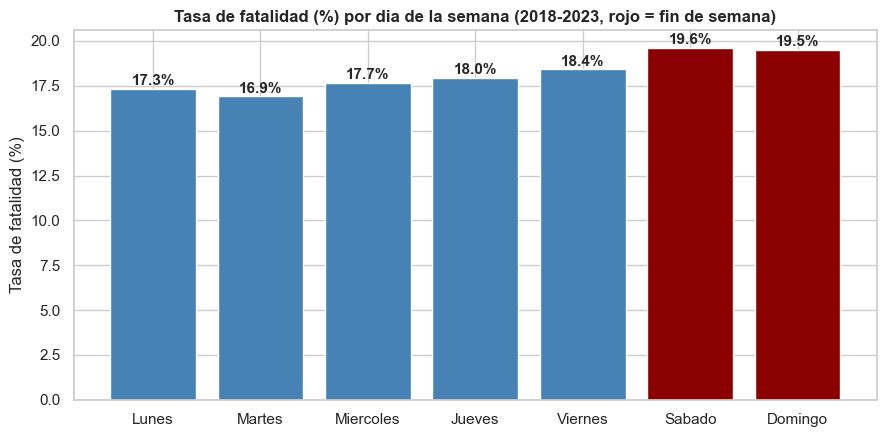

In [24]:
# 4.6 Tasa de fatalidad por dia de la semana
tasa_dia = df_eda.dropna(subset=["dia_semana"]).groupby("dia_semana")["target"].mean() * 100
tasa_dia.index = [MAPA_DIA_SEMANA.get(int(d), d) for d in tasa_dia.index]
tasa_dia = tasa_dia.reindex(list(MAPA_DIA_SEMANA.values()))

plt.figure(figsize=(9, 4.5))
colores_dia = ["steelblue"] * 5 + ["darkred"] * 2  # fin de semana resaltado
plt.bar(tasa_dia.index, tasa_dia.values, color=colores_dia)
for i, v in enumerate(tasa_dia.values):
    plt.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.title("Tasa de fatalidad (%) por dia de la semana (2018-2023, rojo = fin de semana)", fontweight="bold")
plt.ylabel("Tasa de fatalidad (%)")
plt.tight_layout()
plt.savefig("figuras/08_tasa_dia_semana.png", dpi=150)
plt.show()

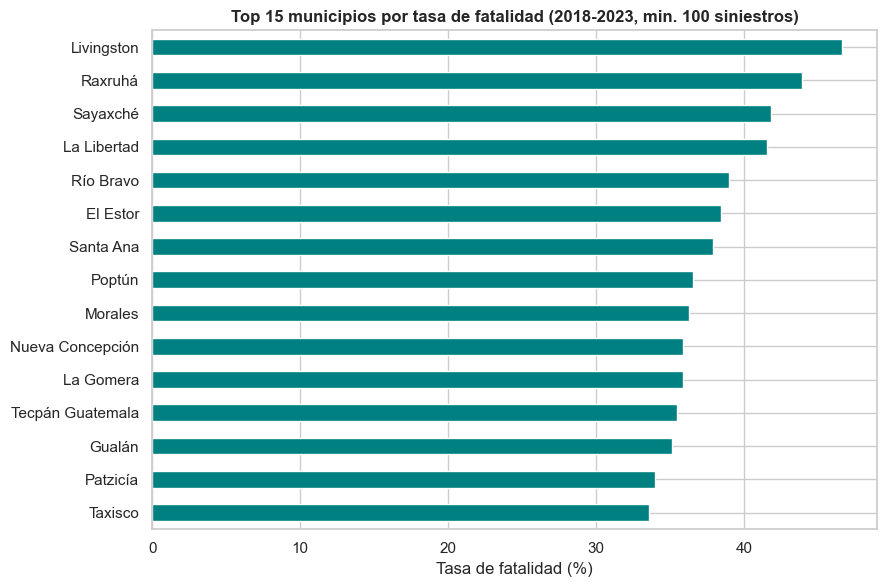

In [25]:
# 4.7 Top 15 municipios por tasa de fatalidad (volumen minimo para evitar ruido estadistico)
resumen_mun = df_eda.groupby("municipio")["target"].agg(["mean", "count"])
resumen_mun = resumen_mun[resumen_mun["count"] >= 100]
top15_mun = (resumen_mun["mean"] * 100).sort_values(ascending=False).head(15)
top15_mun.index = [MAPA_MUNICIPIO.get(c, c) for c in top15_mun.index]

plt.figure(figsize=(9, 6))
top15_mun.sort_values().plot(kind="barh", color="teal")
plt.title("Top 15 municipios por tasa de fatalidad (2018-2023, min. 100 siniestros)", fontweight="bold")
plt.xlabel("Tasa de fatalidad (%)")
plt.tight_layout()
plt.savefig("figuras/09_top15_municipios.png", dpi=150)
plt.show()

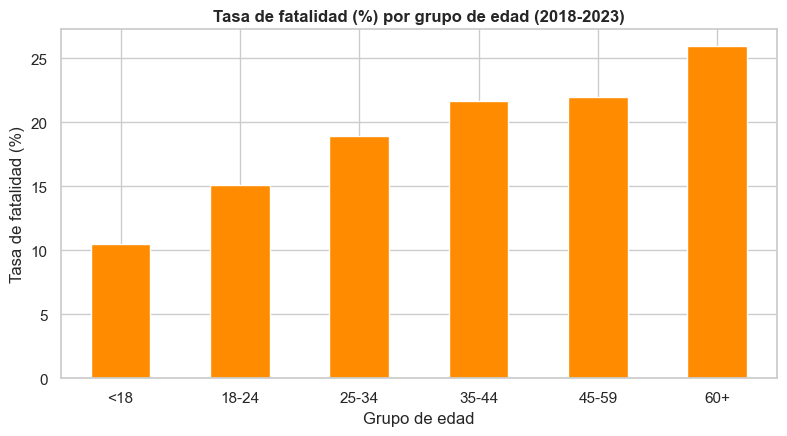

In [26]:
# 4.8 Tasa de fatalidad por grupo de edad
edad_valida = df_eda["edad"].where(df_eda["edad"].between(0, 100))
grupos_edad = pd.cut(edad_valida, bins=[0, 17, 24, 34, 44, 59, 100],
                     labels=["<18", "18-24", "25-34", "35-44", "45-59", "60+"], include_lowest=True)
tasa_edad = df_eda.assign(grupo_edad=grupos_edad).dropna(subset=["grupo_edad"]).groupby("grupo_edad", observed=True)["target"].mean() * 100

plt.figure(figsize=(8, 4.5))
tasa_edad.plot(kind="bar", color="darkorange")
plt.title("Tasa de fatalidad (%) por grupo de edad (2018-2023)", fontweight="bold")
plt.ylabel("Tasa de fatalidad (%)")
plt.xlabel("Grupo de edad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figuras/10_tasa_grupo_edad.png", dpi=150)
plt.show()

**Lectura.** La tasa de fatalidad crece de forma monótona con la edad, de ~11% en menores de 18
años a ~27% en mayores de 60, reflejando mayor fragilidad biológica ante un mismo tipo de impacto.
Esta gradiente es la que respalda el indicador de *edad vulnerable* construido en la sección 5.

---

Con el EDA cerrado, la sección 5 traduce estos patrones en variables utilizables por el modelo.

## 5. Ingeniería de características

A partir de los atributos originales del INE se construyen las variables que efectivamente
alimentan al modelo. Tres decisiones de diseño concentran el aporte de esta sección:

- **Codificación cíclica de hora y mes** (seno/coseno), para que el modelo entienda que la hora 23
  está "cerca" de la hora 0, y diciembre cerca de enero — una continuidad que un entero simple
  rompe. Es la traducción directa del patrón horario observado en la sección 4.2.
- **Frecuencia histórica** para municipio (339 valores distintos) y marca de vehículo (141), en vez
  de One-Hot: codificarlas directamente habría llevado el modelo por encima de 400 columnas,
  complicando tanto el entrenamiento como la lectura de los gráficos de interpretabilidad de la
  sección 8. La frecuencia se calcula **solo sobre 2018–2023** y se reutiliza en 2024, para no
  filtrar información del holdout.
- **Indicadores de vulnerabilidad** por tipo de vehículo y por edad, construidos con los códigos
  oficiales del diccionario del INE (`VEHICULOS_VULNERABLES = {4, 14, 18, 22}`) y no con
  comparaciones contra texto libre, que no coinciden con la codificación numérica de la fuente.

Se agrega además una variable de **feriado / temporada alta vial**, calculada directamente de las
columnas año/mes/día que ya trae el dataset, sin ninguna fuente externa: Semana Santa (con el
algoritmo de Meeus/Jones/Butcher para la fecha de Pascua, que cambia cada año) y fin de año
(20 dic – 2 ene), periodos de alto volumen de viajes interdepartamentales en Guatemala. Se probó
porque la literatura de seguridad vial la señala como relevante y, a diferencia de clima o tipo de
vía (Capítulo 7.3 de la memoria), no requiere conseguir ni cruzar datos de otra fuente. Su aporte
real se cuantifica más abajo con la V de Cramér, y en la sección 6 con validación cruzada.

In [29]:
def franja_horaria(hora):
    if pd.isna(hora):
        return "Desconocido"
    hora = int(hora)
    if 0 <= hora < 6:
        return "Madrugada"
    if 6 <= hora < 12:
        return "Manana"
    if 12 <= hora < 18:
        return "Tarde"
    return "Noche"


def calcular_domingo_pascua(anio):
    """Fecha del Domingo de Pascua (calendario gregoriano). Algoritmo de Meeus/Jones/Butcher --
    no depende de ninguna libreria ni fuente de datos externa, solo aritmetica sobre el anio."""
    a = anio % 19
    b = anio // 100
    c = anio % 100
    d_ = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d_ - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    mes = (h + l - 7 * m + 114) // 31
    dia = ((h + l - 7 * m + 114) % 31) + 1
    return date(int(anio), int(mes), int(dia))


# Feriados fijos (mes, dia) del calendario oficial de Guatemala.
FERIADOS_FIJOS = {(1, 1), (5, 1), (9, 15), (10, 20), (11, 1), (12, 24), (12, 25), (12, 31)}
# Ventana de Semana Santa (Jueves Santo -> Domingo de Pascua) por anio, calculada una sola vez.
VENTANAS_SEMANA_SANTA = {
    anio: (calcular_domingo_pascua(anio) - timedelta(days=3), calcular_domingo_pascua(anio))
    for anio in range(2017, 2026)
}


def calcular_feriado_y_temporada_alta(row):
    """Feriado oficial y temporada alta vial (Semana Santa + fin de ano), calculados solo a
    partir de anio/mes/dia -- no requieren ninguna fuente de datos externa."""
    anio, mes, dia = row["anio"], row["mes"], row["dia"]
    if pd.isna(anio) or pd.isna(mes) or pd.isna(dia):
        return pd.Series([0, 0])
    try:
        fecha = date(int(anio), int(mes), int(dia))
    except ValueError:
        return pd.Series([0, 0])
    inicio_ss, fin_ss = VENTANAS_SEMANA_SANTA.get(int(anio), (None, None))
    en_semana_santa = inicio_ss is not None and inicio_ss <= fecha <= fin_ss
    en_fin_de_anio = (fecha.month == 12 and fecha.day >= 20) or (fecha.month == 1 and fecha.day <= 2)
    es_feriado = int((fecha.month, fecha.day) in FERIADOS_FIJOS or en_semana_santa)
    es_temporada_alta = int(en_semana_santa or en_fin_de_anio)
    return pd.Series([es_feriado, es_temporada_alta])


def aplicar_feature_engineering(d, frecuencias=None):
    d = d.copy()
    d["franja_horaria"] = d["hora"].apply(franja_horaria)

    # Fin de semana como categoria explicita de 3 estados: el 31% de los registros no trae
    # dia_semana, y asumir silenciosamente "no es fin de semana" para ese 31% sesga el analisis.
    d["es_fin_de_semana"] = np.select(
        [d["dia_semana"].isna(), d["dia_semana"].isin([6, 7])],
        ["Desconocido", "Fin de semana"],
        default="Entre semana",
    )
    d["es_horario_critico"] = ((d["franja_horaria"] == "Madrugada") & (d["es_fin_de_semana"] == "Fin de semana")).astype(int)
    d["vehiculo_vulnerable"] = d["tipo_vehiculo"].isin(VEHICULOS_VULNERABLES).astype(int)
    d["edad_vulnerable"] = ((d["edad"] < 18) | (d["edad"] >= 60)).astype(int)
    d["vulnerabilidad_vehiculo_edad"] = (d["vehiculo_vulnerable"] & d["edad_vulnerable"]).astype(int)
    d[["es_feriado", "es_temporada_alta_vial"]] = d.apply(calcular_feriado_y_temporada_alta, axis=1)

    # Codificacion ciclica: preserva la continuidad hora=23 <-> hora=0 y mes=12 <-> mes=1
    hora_rellena = d["hora"].fillna(d["hora"].median())
    d["hora_sin"] = np.sin(2 * np.pi * hora_rellena / 24)
    d["hora_cos"] = np.cos(2 * np.pi * hora_rellena / 24)
    d["mes_sin"] = np.sin(2 * np.pi * d["mes"] / 12)
    d["mes_cos"] = np.cos(2 * np.pi * d["mes"] / 12)

    # Frecuencia historica de municipio y marca (calculadas SOLO sobre 2018-2023 y reutilizadas
    # en 2024, para no filtrar informacion del futuro hacia el pasado). Se usa frecuencia en vez
    # de One-Hot Encoding porque municipio (339 valores) y marca (141 valores) son de alta
    # cardinalidad: codificarlas directamente dispararia el numero de columnas a mas de 400,
    # lo cual ademas de innecesario complicaba la interpretabilidad con SHAP.
    if frecuencias is None:
        frecuencias = {
            "municipio": d["municipio"].value_counts(normalize=True),
            "marca_vehiculo": d["marca_vehiculo"].value_counts(normalize=True),
        }
    d["municipio_freq"] = d["municipio"].map(frecuencias["municipio"]).fillna(0)
    d["marca_freq"] = d["marca_vehiculo"].map(frecuencias["marca_vehiculo"]).fillna(0)

    return d, frecuencias


df_eda, frecuencias_train = aplicar_feature_engineering(df_eda)
df_oot, _ = aplicar_feature_engineering(df_oot, frecuencias=frecuencias_train)

print("Distribucion de vehiculo_vulnerable (2018-2023):")
print(df_eda["vehiculo_vulnerable"].value_counts(normalize=True).round(3))
print("\nDistribucion de es_fin_de_semana (2018-2023):")
print(df_eda["es_fin_de_semana"].value_counts(normalize=True).round(3))


Distribucion de vehiculo_vulnerable (2018-2023):
vehiculo_vulnerable
1    0.542
0    0.458
Name: proportion, dtype: float64

Distribucion de es_fin_de_semana (2018-2023):
es_fin_de_semana
Entre semana     0.506
Fin de semana    0.310
Desconocido      0.185
Name: proportion, dtype: float64


### Fuerza de asociación de cada variable con la severidad (V de Cramér)

Antes de fijar la lista final de variables del modelo, se cuantifica qué tan asociada está cada
una con el target usando la V de Cramér (basada en chi-cuadrado; 0 = sin asociación, 1 = asociación
perfecta). Esto reemplaza la selección "a ojo" por un criterio estadístico explícito y es lo que
justifica, por ejemplo, incluir `tipo_evento` y excluir variables más débiles como `color_vehiculo`.


In [31]:
def v_cramer(col, target_col="severidad_label", data=df_eda):
    tabla = pd.crosstab(data[col], data[target_col])
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

candidatas = ["departamento", "municipio", "tipo_vehiculo", "tipo_evento", "sexo",
              "marca_vehiculo", "color_vehiculo", "franja_horaria", "es_fin_de_semana",
              "vehiculo_vulnerable", "edad_vulnerable", "es_feriado", "es_temporada_alta_vial"]
candidatas = [c for c in candidatas if c in df_eda.columns]

asociacion = pd.Series({c: v_cramer(c) for c in candidatas}, name="V_Cramer").sort_values(ascending=False)
print(asociacion.round(4))


municipio                 0.2030
tipo_vehiculo             0.1726
marca_vehiculo            0.1606
tipo_evento               0.1602
departamento              0.1534
sexo                      0.1324
color_vehiculo            0.1255
franja_horaria            0.0926
edad_vulnerable           0.0384
vehiculo_vulnerable       0.0310
es_fin_de_semana          0.0285
es_feriado                0.0084
es_temporada_alta_vial    0.0005
Name: V_Cramer, dtype: float64


### Multicolinealidad entre las variables numéricas candidatas

Además de la asociación con la severidad (arriba), se revisa la correlación entre las variables
numéricas candidatas entre sí, con el criterio habitual de descartar pares con |r| >= 0.80-0.90 por
redundantes. La revisión se limita a las variables numéricas continuas: para las categóricas ya
seleccionadas con la V de Cramér, la multicolinealidad importa mucho menos, porque los modelos de
árboles de decisión (Random Forest, HistGradientBoosting, XGBoost, LightGBM) son en la práctica
invariantes a variables redundantes o correlacionadas entre sí -- a diferencia de un modelo lineal,
donde sí distorsionaría los coeficientes. Por eso este criterio se aplica aquí solo como
verificación adicional de higiene de datos, no como paso obligatorio del pipeline.


In [33]:
NUM_CANDIDATAS_CORR = ["edad", "hora", "mes", "dia", "hora_sin", "hora_cos", "mes_sin", "mes_cos",
                       "municipio_freq", "marca_freq"]
NUM_CANDIDATAS_CORR = [c for c in NUM_CANDIDATAS_CORR if c in df_eda.columns]

matriz_corr = df_eda[NUM_CANDIDATAS_CORR].corr()
print("Matriz de correlacion (Pearson) entre variables numericas candidatas:")
print(matriz_corr.round(3))

# Pares con correlacion alta (umbral habitual 0.80-0.90), excluyendo la diagonal.
pares_altos = (
    matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    .stack()
    .loc[lambda s: s.abs() >= 0.80]
    .sort_values(key=abs, ascending=False)
)
if pares_altos.empty:
    print("\nNingun par de variables numericas supera |r| = 0.80 -- no hay redundancia que justifique descartar alguna.")
else:
    print("\nPares con |r| >= 0.80 (candidatos a redundantes):")
    print(pares_altos.round(3))


Matriz de correlacion (Pearson) entre variables numericas candidatas:
                 edad   hora    mes    dia  hora_sin  hora_cos  mes_sin  \
edad            1.000 -0.007  0.006  0.002     0.030    -0.050   -0.007   
hora           -0.007  1.000 -0.007 -0.000    -0.765     0.075    0.008   
mes             0.006 -0.007  1.000  0.036     0.001     0.035   -0.751   
dia             0.002 -0.000  0.036  1.000    -0.005     0.003   -0.035   
hora_sin        0.030 -0.765  0.001 -0.005     1.000    -0.115   -0.004   
hora_cos       -0.050  0.075  0.035  0.003    -0.115     1.000   -0.013   
mes_sin        -0.007  0.008 -0.751 -0.035    -0.004    -0.013    1.000   
mes_cos        -0.003 -0.008  0.217  0.023     0.014     0.043    0.005   
municipio_freq  0.022 -0.032  0.020 -0.006     0.057     0.056   -0.020   
marca_freq      0.030  0.019 -0.012 -0.000    -0.004     0.037   -0.000   

                mes_cos  municipio_freq  marca_freq  
edad             -0.003           0.022       0.03

## 6. Modelado, validación cruzada y selección de modelo

Se comparan cinco algoritmos, todos con ponderación de clases para tratar el desbalance 81/19:
regresión logística (línea base lineal interpretable), Random Forest,
`HistGradientBoostingClassifier`, XGBoost y LightGBM. Los tres últimos pertenecen a la misma
familia de boosting sobre árboles; incluir las tres implementaciones permite verificar
explícitamente si la elección de librería cambia el resultado — el Capítulo 4.3 de la memoria
documenta que no lo cambia de forma material.

La celda siguiente detecta automáticamente qué librerías están instaladas en el entorno y arma la
comparativa con las que encuentre.

La validación es **5-fold estratificada, siempre sobre 2018–2023**. El año 2024 no participa en
ninguna decisión de esta sección.

In [35]:
num_features = ["edad", "hora", "mes", "dia", "hora_sin", "hora_cos", "mes_sin", "mes_cos",
                "municipio_freq", "marca_freq"]
cat_features = ["sexo", "departamento", "tipo_vehiculo", "tipo_evento",
                "franja_horaria", "es_fin_de_semana", "es_horario_critico",
                "vehiculo_vulnerable", "edad_vulnerable", "vulnerabilidad_vehiculo_edad",
                "es_feriado", "es_temporada_alta_vial"]
# Nota: marca_vehiculo y municipio NO se codifican con One-Hot: tienen 141 y 339 valores
# distintos respectivamente, lo que dispararia el numero de columnas post-encoding a mas de
# 400 y complicaria innecesariamente tanto el entrenamiento como la lectura del grafico SHAP.
# En su lugar se usa la frecuencia historica de cada categoria (marca_freq, municipio_freq),
# ya calculada en la seccion de Feature Engineering.
features = num_features + cat_features

X = df_eda[features].copy()
y = df_eda["target"].values
X_oot = df_oot[features].copy()
y_oot = df_oot["target"].values

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_features),
])

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=14, class_weight="balanced",
                                            n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=8,
                                                            l2_regularization=1.0, random_state=RANDOM_STATE),
}

# Boosting basado en arboles (misma familia que HistGradientBoosting) que ademas reciben peso de
# muestra en el fit, igual que HistGradientBoosting -- se agregan solo si estan instalados, para
# que el notebook siga siendo reproducible en un entorno que no los tenga.
MODELOS_CON_SAMPLE_WEIGHT = ["HistGradientBoosting"]

if XGBOOST_DISPONIBLE:
    modelos["XGBoost"] = XGBClassifier(n_estimators=300, learning_rate=0.06, max_depth=8,
                                        reg_lambda=1.0, eval_metric="logloss",
                                        random_state=RANDOM_STATE, n_jobs=-1)
    MODELOS_CON_SAMPLE_WEIGHT.append("XGBoost")

if LIGHTGBM_DISPONIBLE:
    modelos["LightGBM"] = LGBMClassifier(n_estimators=300, learning_rate=0.06, max_depth=8,
                                          reg_lambda=1.0, random_state=RANDOM_STATE,
                                          n_jobs=-1, verbose=-1)
    MODELOS_CON_SAMPLE_WEIGHT.append("LightGBM")

print(f"Modelos incluidos en la comparativa: {list(modelos.keys())}")
if not (XGBOOST_DISPONIBLE and LIGHTGBM_DISPONIBLE):
    print("(XGBoost y/o LightGBM no estan instalados en este entorno -- se omiten sin romper el notebook.)")


Modelos incluidos en la comparativa: ['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM']


In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = {nombre: {"roc_auc": [], "pr_auc": [], "recall_fatal": [], "precision_fatal": [], "f1_fatal": []}
                 for nombre in modelos}

for fold, (idx_tr, idx_val) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y[idx_tr], y[idx_val]

    X_tr_prep = preprocessor.fit_transform(X_tr)
    X_val_prep = preprocessor.transform(X_val)
    pesos = np.where(y_tr == 1, (y_tr == 0).sum() / (y_tr == 1).sum(), 1.0)

    for nombre, modelo_base in modelos.items():
        modelo = modelo_base.__class__(**modelo_base.get_params())
        if nombre in MODELOS_CON_SAMPLE_WEIGHT:
            modelo.fit(X_tr_prep, y_tr, sample_weight=pesos)
        else:
            modelo.fit(X_tr_prep, y_tr)

        probs = modelo.predict_proba(X_val_prep)[:, 1]
        preds = (probs >= 0.5).astype(int)
        resultados_cv[nombre]["roc_auc"].append(roc_auc_score(y_val, probs))
        resultados_cv[nombre]["pr_auc"].append(average_precision_score(y_val, probs))
        resultados_cv[nombre]["recall_fatal"].append(recall_score(y_val, preds))
        resultados_cv[nombre]["precision_fatal"].append(precision_score(y_val, preds, zero_division=0))
        resultados_cv[nombre]["f1_fatal"].append(f1_score(y_val, preds, zero_division=0))

    print(f"Fold {fold}/5 completado")

resumen_cv = pd.DataFrame({n: {m: np.mean(v) for m, v in r.items()} for n, r in resultados_cv.items()}).T
print("\nResultados de validacion cruzada (5-fold, 2018-2023, umbral 0.5):")
resumen_cv.round(4)


Fold 1/5 completado
Fold 2/5 completado
Fold 3/5 completado
Fold 4/5 completado
Fold 5/5 completado

Resultados de validacion cruzada (5-fold, 2018-2023, umbral 0.5):


,roc_auc,pr_auc,recall_fatal,precision_fatal,f1_fatal
LogisticRegression,0.7245,0.3987,0.6549,0.3137,0.4242
RandomForest,0.7605,0.4617,0.5437,0.4081,0.4662
HistGradientBoosting,0.7685,0.4697,0.6595,0.3638,0.4689
XGBoost,0.7715,0.4808,0.6018,0.3959,0.4776
LightGBM,0.7720,0.4772,0.6510,0.3694,0.4713


## 6.1 Ajuste fino de hiperparámetros nativos de LightGBM

La comparativa anterior usó los mismos tres hiperparámetros genéricos (`learning_rate`, `max_depth`,
regularización) para poder comparar los cinco modelos en igualdad de condiciones. Esta sección va un
paso más allá y ajusta los hiperparámetros **propios** de LightGBM (`num_leaves`, `min_child_samples`,
submuestreo de filas y columnas) mediante una búsqueda aleatoria más amplia — 60 combinaciones × 5-fold
= 300 ajustes, siempre sobre 2018–2023. El resultado se evalúa, una única vez, sobre el holdout real
de 2024, siguiendo la misma disciplina Out-of-Time del resto del trabajo.


In [38]:
if LIGHTGBM_DISPONIBLE:
    espacio_busqueda_lgbm = {
        "modelo__num_leaves": [15, 31, 63, 127],
        "modelo__max_depth": [-1, 6, 8, 10, 12],
        "modelo__min_child_samples": [10, 20, 50, 100],
        "modelo__learning_rate": [0.03, 0.05, 0.06, 0.08, 0.1],
        "modelo__n_estimators": [200, 300, 500, 800],
        "modelo__subsample": [0.7, 0.8, 0.9, 1.0],
        "modelo__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "modelo__reg_lambda": [0.0, 0.5, 1.0, 2.0, 5.0],
        "modelo__reg_alpha": [0.0, 0.5, 1.0],
    }

    pipeline_lgbm = Pipeline([
        ("preprocessor", preprocessor),
        ("modelo", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)),
    ])

    pesos_busqueda = np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

    busqueda_lgbm = RandomizedSearchCV(
        pipeline_lgbm,
        param_distributions=espacio_busqueda_lgbm,
        n_iter=60,
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    # Puede tardar varios minutos (300 ajustes en total).
    busqueda_lgbm.fit(X, y, modelo__sample_weight=pesos_busqueda)

    print("=== BUSQUEDA DE HIPERPARAMETROS NATIVOS - LIGHTGBM (60 x 5-fold = 300 ajustes) ===")
    print("Mejores hiperparametros encontrados:")
    for k, v in busqueda_lgbm.best_params_.items():
        print(f"  {k.replace('modelo__', '')}: {v}")
    print(f"Mejor ROC-AUC en validacion cruzada: {busqueda_lgbm.best_score_:.4f}")
    print(f"(ROC-AUC de LightGBM con hiperparametros por defecto, para comparar: "
      f"{resumen_cv.loc['LightGBM', 'roc_auc']:.4f})")

    # Evaluacion, una sola vez, sobre el holdout real 2024 -- igual que en la Seccion 7.
    probs_oot_tuneado = busqueda_lgbm.best_estimator_.predict_proba(X_oot)[:, 1]
    preds_oot_tuneado = (probs_oot_tuneado >= 0.5).astype(int)
    print("\n=== METRICAS DEL LIGHTGBM AJUSTADO SOBRE EL HOLDOUT REAL 2024 ===")
    print(f"ROC-AUC:               {roc_auc_score(y_oot, probs_oot_tuneado):.4f}")
    print(f"PR-AUC:                {average_precision_score(y_oot, probs_oot_tuneado):.4f}")
    print(f"Recall (Fallecido):    {recall_score(y_oot, preds_oot_tuneado):.4f}")
    print(f"Precision (Fallecido): {precision_score(y_oot, preds_oot_tuneado):.4f}")
    print(f"F1 (Fallecido):        {f1_score(y_oot, preds_oot_tuneado):.4f}")
    print("(El mismo LightGBM con hiperparametros por defecto se evalua sobre este holdout en "
          "la Seccion 7; alli estan los numeros oficiales con los que se compara esta busqueda.)")
else:
    print("LightGBM no esta instalado en este entorno -- se omite esta busqueda de hiperparametros nativa.")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
=== BUSQUEDA DE HIPERPARAMETROS NATIVOS - LIGHTGBM (60 x 5-fold = 300 ajustes) ===
Mejores hiperparametros encontrados:
  subsample: 1.0
  reg_lambda: 1.0
  reg_alpha: 1.0
  num_leaves: 31
  n_estimators: 800
  min_child_samples: 10
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.6
Mejor ROC-AUC en validacion cruzada: 0.7770
(ROC-AUC de LightGBM con hiperparametros por defecto, para comparar: 0.7720)

=== METRICAS DEL LIGHTGBM AJUSTADO SOBRE EL HOLDOUT REAL 2024 ===
ROC-AUC:               0.7406
PR-AUC:                0.4694
Recall (Fallecido):    0.6596
Precision (Fallecido): 0.3541
F1 (Fallecido):        0.4609
(El mismo LightGBM con hiperparametros por defecto se evalua sobre este holdout en la Seccion 7; alli estan los numeros oficiales con los que se compara esta busqueda.)


## 6.2 Verificación adicional: búsqueda bayesiana de hiperparámetros (Optuna)

La búsqueda anterior (`RandomizedSearchCV`) explora el espacio de hiperparámetros por muestreo
aleatorio uniforme, sin aprender de los resultados de intentos anteriores. Optuna implementa un
algoritmo de optimización bayesiana (*Tree-structured Parzen Estimator*, TPE) que sí aprende de
cada intento y concentra la búsqueda en las zonas más prometedoras del espacio de hiperparámetros.
Esta sección repite la búsqueda de hiperparámetros nativos de LightGBM con Optuna, usando exactamente
el **mismo espacio de búsqueda y el mismo presupuesto** (60 intentos × 5-fold = 300 ajustes) que la
sección anterior, de modo que la comparación aísle la estrategia de búsqueda y no mezcle otras
variables. Puede tardar varios minutos adicionales.


In [40]:
if LIGHTGBM_DISPONIBLE and OPTUNA_DISPONIBLE:
    espacio_optuna = {
        "num_leaves": [15, 31, 63, 127],
        "max_depth": [-1, 6, 8, 10, 12],
        "min_child_samples": [10, 20, 50, 100],
        "learning_rate": [0.03, 0.05, 0.06, 0.08, 0.1],
        "n_estimators": [200, 300, 500, 800],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "reg_lambda": [0.0, 0.5, 1.0, 2.0, 5.0],
        "reg_alpha": [0.0, 0.5, 1.0],
    }

    skf_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objetivo_optuna(trial):
        params = {nombre: trial.suggest_categorical(nombre, valores)
                  for nombre, valores in espacio_optuna.items()}
        scores = []
        for idx_tr, idx_val in skf_optuna.split(X, y):
            X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
            y_tr, y_val = y[idx_tr], y[idx_val]
            X_tr_p = preprocessor.fit_transform(X_tr)
            X_val_p = preprocessor.transform(X_val)
            pesos_tr = np.where(y_tr == 1, (y_tr == 0).sum() / (y_tr == 1).sum(), 1.0)
            modelo = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1, **params)
            modelo.fit(X_tr_p, y_tr, sample_weight=pesos_tr)
            probs = modelo.predict_proba(X_val_p)[:, 1]
            scores.append(roc_auc_score(y_val, probs))
        return float(np.mean(scores))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    estudio_lgbm = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
    # Mismo presupuesto que la busqueda aleatoria anterior (300 ajustes); puede tardar varios minutos.
    estudio_lgbm.optimize(objetivo_optuna, n_trials=60, show_progress_bar=False)

    print("=== BUSQUEDA BAYESIANA (OPTUNA) - LIGHTGBM (60 intentos x 5-fold = 300 ajustes) ===")
    print("Mejores hiperparametros encontrados:")
    for k, v in estudio_lgbm.best_params.items():
        print(f"  {k}: {v}")
    print(f"Mejor ROC-AUC en validacion cruzada: {estudio_lgbm.best_value:.4f}")
    print(f"(Para comparar, RandomizedSearchCV (Seccion 6.1) encontro: {busqueda_lgbm.best_score_:.4f})")

    # Reentrenamiento con todo 2018-2023 y evaluacion, una sola vez, sobre el holdout real 2024.
    preprocessor.fit(X)
    X_prep_optuna = preprocessor.transform(X)
    X_oot_prep_optuna = preprocessor.transform(X_oot)
    pesos_full_optuna = np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

    modelo_optuna_final = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                          **estudio_lgbm.best_params)
    modelo_optuna_final.fit(X_prep_optuna, y, sample_weight=pesos_full_optuna)

    probs_oot_optuna = modelo_optuna_final.predict_proba(X_oot_prep_optuna)[:, 1]
    preds_oot_optuna = (probs_oot_optuna >= 0.5).astype(int)
    print("\n=== METRICAS DEL LIGHTGBM AJUSTADO CON OPTUNA SOBRE EL HOLDOUT REAL 2024 ===")
    print(f"ROC-AUC:               {roc_auc_score(y_oot, probs_oot_optuna):.4f}")
    print(f"PR-AUC:                {average_precision_score(y_oot, probs_oot_optuna):.4f}")
    print(f"Recall (Fallecido):    {recall_score(y_oot, preds_oot_optuna):.4f}")
    print(f"Precision (Fallecido): {precision_score(y_oot, preds_oot_optuna):.4f}")
    print(f"F1 (Fallecido):        {f1_score(y_oot, preds_oot_optuna):.4f}")
    print("(Para comparar: la busqueda aleatoria equivalente esta en la Seccion 6.1 y el modelo "
          "con hiperparametros por defecto en la Seccion 7, ambos sobre este mismo holdout.)")
elif LIGHTGBM_DISPONIBLE and not OPTUNA_DISPONIBLE:
    print("Optuna no esta instalado en este entorno (pip install optuna) -- se omite esta verificacion.")
else:
    print("LightGBM no esta instalado en este entorno -- se omite esta busqueda de hiperparametros con Optuna.")


=== BUSQUEDA BAYESIANA (OPTUNA) - LIGHTGBM (60 intentos x 5-fold = 300 ajustes) ===
Mejores hiperparametros encontrados:
  num_leaves: 63
  max_depth: 8
  min_child_samples: 10
  learning_rate: 0.05
  n_estimators: 500
  subsample: 0.7
  colsample_bytree: 0.6
  reg_lambda: 5.0
  reg_alpha: 0.0
Mejor ROC-AUC en validacion cruzada: 0.7767
(Para comparar, RandomizedSearchCV (Seccion 6.1) encontro: 0.7770)

=== METRICAS DEL LIGHTGBM AJUSTADO CON OPTUNA SOBRE EL HOLDOUT REAL 2024 ===
ROC-AUC:               0.7377
PR-AUC:                0.4633
Recall (Fallecido):    0.6630
Precision (Fallecido): 0.3550
F1 (Fallecido):        0.4624
(Para comparar: la busqueda aleatoria equivalente esta en la Seccion 6.1 y el modelo con hiperparametros por defecto en la Seccion 7, ambos sobre este mismo holdout.)


## 7. Evaluación final sobre el holdout Out-of-Time 2024

El modelo ganador de la validación cruzada se reentrena con **todo** 2018–2023 y se evalúa
**una sola vez** sobre 2024, que hasta este punto no ha participado en ninguna decisión de
modelado. Este es el número que debe citarse en la memoria.


=== METRICAS FINALES SOBRE 2024 (OUT-OF-TIME REAL) ===
ROC-AUC:            0.7404
PR-AUC:             0.4687
Recall (Fallecido): 0.6778
Precision (Fallecido): 0.3567
F1 (Fallecido):     0.4674

              precision    recall  f1-score   support

   Lesionado       0.89      0.68      0.77      8907
   Fallecido       0.36      0.68      0.47      2365

    accuracy                           0.68     11272
   macro avg       0.62      0.68      0.62     11272
weighted avg       0.78      0.68      0.70     11272



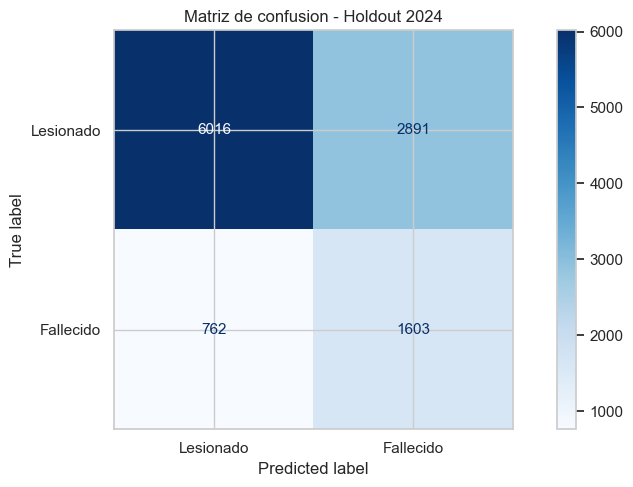

In [42]:
MODELO_GANADOR = "LightGBM"  # actualizar segun cual haya ganado en la celda anterior

X_prep_full = preprocessor.fit_transform(X)
X_oot_prep = preprocessor.transform(X_oot)
pesos_full = np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

# Se reconstruye a partir del diccionario `modelos` (misma configuracion que se comparo en la
# validacion cruzada) en vez de repetir los hiperparametros a mano, para que esta celda nunca
# quede desincronizada de la comparativa de la seccion anterior.
modelo_final = modelos[MODELO_GANADOR].__class__(**modelos[MODELO_GANADOR].get_params())
if MODELO_GANADOR in MODELOS_CON_SAMPLE_WEIGHT:
    modelo_final.fit(X_prep_full, y, sample_weight=pesos_full)
else:
    modelo_final.fit(X_prep_full, y)

probs_oot = modelo_final.predict_proba(X_oot_prep)[:, 1]
preds_oot = (probs_oot >= 0.5).astype(int)

print("=== METRICAS FINALES SOBRE 2024 (OUT-OF-TIME REAL) ===")
print(f"ROC-AUC:            {roc_auc_score(y_oot, probs_oot):.4f}")
print(f"PR-AUC:             {average_precision_score(y_oot, probs_oot):.4f}")
print(f"Recall (Fallecido): {recall_score(y_oot, preds_oot):.4f}")
print(f"Precision (Fallecido): {precision_score(y_oot, preds_oot):.4f}")
print(f"F1 (Fallecido):     {f1_score(y_oot, preds_oot):.4f}")
print()
print(classification_report(y_oot, preds_oot, target_names=["Lesionado", "Fallecido"]))

ConfusionMatrixDisplay(confusion_matrix(y_oot, preds_oot), display_labels=["Lesionado", "Fallecido"]).plot(cmap="Blues")
plt.title("Matriz de confusion - Holdout 2024")
plt.tight_layout()
plt.savefig("figuras/05_matriz_confusion_oot.png", dpi=150)
plt.show()


## 8. Interpretabilidad (SHAP)

Se descompone la predicción del modelo con SHAP (*SHapley Additive exPlanations*) para pasar de un
score opaco a una explicación por variable: qué empuja la probabilidad de fatalidad hacia arriba y
qué la empuja hacia abajo, tanto a nivel global (importancia media) como para un caso individual.
Los gráficos generados aquí son los que se reproducen en el Capítulo 5 de la memoria.

**Sobre el tamaño de muestra.** Los valores SHAP se calculan sobre el **holdout 2024 completo**, no
sobre una submuestra: `TreeExplainer` es exacto para modelos de árboles y su costo crece de forma
lineal con el número de filas, así que no hay razón para recortar el cálculo. El único motivo por el
que podría interesar submuestrear es el gráfico —el diagrama de enjambre dibuja un punto por caso y
por variable, y se satura visualmente cuando hay demasiados—, y para no elegir ese número a ojo la
celda mide primero **a partir de qué tamaño de muestra el ranking del top-15 deja de cambiar**
respecto al del holdout completo. Esa comprobación es prácticamente gratuita, porque submuestrea los
valores SHAP ya calculados en vez de recalcularlos.

Requiere la librería `shap` instalada en el entorno (ver `requirements.txt`).

Casos sobre los que se calcula SHAP: 11,272 (holdout 2024 completo)
Columnas que ve SHAP:                84
Explainer usado: TreeExplainer

=== ESTABILIDAD DEL TOP-15 SEGUN EL TAMANO DE MUESTRA ===
(referencia: ranking sobre los 11,272 casos del holdout completo; 25 repeticiones por tamano)
      N  % del holdout  coincidencias medias  peor caso
    250           2.2%                15.00/15      15/15
    500           4.4%                15.00/15      15/15
   1000           8.9%                15.00/15      15/15
   2000          17.7%                15.00/15      15/15
   4000          35.5%                15.00/15      15/15
   8000          71.0%                15.00/15      15/15

El top-15 coincide al 100% con el del holdout completo en las 25 repeticiones a partir de N = 250 (2.2% del holdout).


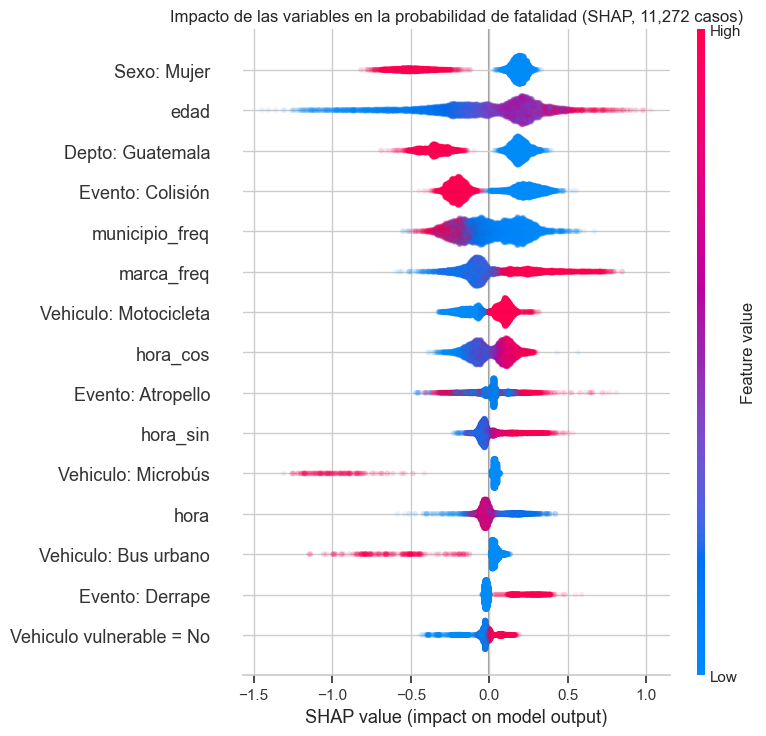

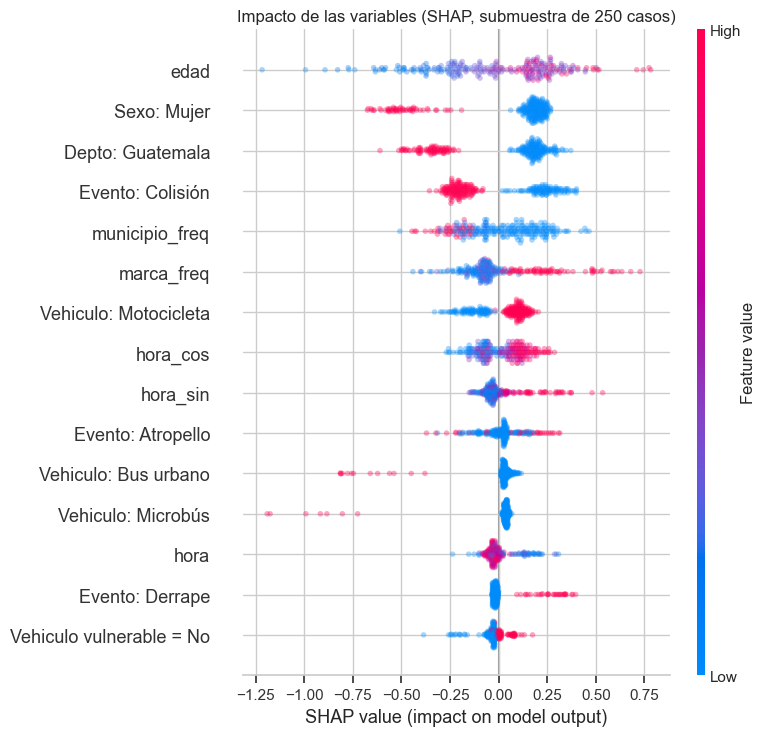


Se guardaron dos versiones del grafico para comparar legibilidad:
  figuras/06_shap_summary.png              (11,272 casos)
  figuras/06b_shap_summary_submuestra.png  (250 casos)


In [44]:
import shap

# ---------------------------------------------------------------------------
# 1. Valores SHAP sobre el holdout COMPLETO
# ---------------------------------------------------------------------------
# TreeExplainer es exacto sobre modelos de arboles y su costo crece de forma lineal con el
# numero de filas, asi que no hay motivo para submuestrear el CALCULO: se usan los casos
# completos del holdout 2024. Cualquier submuestreo posterior afecta solo al grafico.
nombres_cat = preprocessor.named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(cat_features)
nombres_features = num_features + list(nombres_cat)

# Traduccion de codigos a etiquetas legibles, solo para el grafico (el modelo sigue viendo los
# codigos). MAPA_DEPARTAMENTO, MAPA_TIPO_VEHICULO, MAPA_TIPO_EVENTO y MAPA_SEXO se cargan en la
# Seccion 1 desde el diccionario oficial del INE.
ETIQUETAS_BINARIAS = {
    "es_horario_critico": "Horario critico (madrugada finde)",
    "vehiculo_vulnerable": "Vehiculo vulnerable", "edad_vulnerable": "Edad vulnerable (<18 o >=60)",
    "vulnerabilidad_vehiculo_edad": "Vehiculo vulnerable + edad vulnerable",
    "es_feriado": "Feriado oficial", "es_temporada_alta_vial": "Temporada alta vial (Semana Santa/fin de anio)",
}

def etiqueta_legible(nombre_col):
    for prefijo, mapa, etiqueta in [
        ("departamento_", MAPA_DEPARTAMENTO, "Depto"),
        ("tipo_vehiculo_", MAPA_TIPO_VEHICULO, "Vehiculo"),
        ("tipo_evento_", MAPA_TIPO_EVENTO, "Evento"),
        ("sexo_", MAPA_SEXO, "Sexo"),
    ]:
        if nombre_col.startswith(prefijo):
            codigo = nombre_col[len(prefijo):]
            try:
                return f"{etiqueta}: {mapa.get(int(float(codigo)), codigo)}"
            except ValueError:
                return nombre_col
    for base, etiqueta in ETIQUETAS_BINARIAS.items():
        if nombre_col.startswith(base + "_"):
            valor = nombre_col[len(base) + 1:]
            return f"{etiqueta} = {'Si' if valor == '1' else 'No'}"
    return nombre_col

X_oot_df = pd.DataFrame(X_oot_prep, columns=[etiqueta_legible(c) for c in nombres_features])
print(f"Casos sobre los que se calcula SHAP: {X_oot_df.shape[0]:,} (holdout 2024 completo)")
print(f"Columnas que ve SHAP:                {X_oot_df.shape[1]}")

# LightGBM es un modelo de arboles, asi que TreeExplainer es la opcion correcta: exacto (no
# aproximado) y mucho mas rapido que el Explainer generico, que intenta inferir el algoritmo y
# puede fallar segun la combinacion de versiones de sklearn/shap.
try:
    explainer = shap.TreeExplainer(modelo_final)
    shap_values = explainer(X_oot_df)
    print("Explainer usado: TreeExplainer")
except Exception as e:
    print(f"TreeExplainer fallo ({type(e).__name__}: {e}); usando shap.Explainer generico como respaldo.")
    explainer = shap.Explainer(modelo_final, X_oot_df)
    shap_values = explainer(X_oot_df)
    print("Explainer usado: Explainer generico")

# En clasificacion binaria TreeExplainer puede devolver una dimension extra (una capa por
# clase). Nos quedamos con la clase positiva (Fallecido = 1).
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# ---------------------------------------------------------------------------
# 2. Estabilidad del ranking frente al tamano de muestra
# ---------------------------------------------------------------------------
# El ranking de referencia es el calculado sobre el holdout completo. Para cada tamano de
# submuestra se repite el calculo con varias semillas y se mide cuantas de las 15 variables mas
# importantes del ranking completo siguen apareciendo en el top-15 de la submuestra.
# No se recalcula SHAP: se submuestrean los valores ya calculados, asi que el costo es marginal.
# El objetivo es elegir el tamano del grafico a partir del dato y no por conveniencia.
N_TOTAL = shap_values.values.shape[0]
importancia_completa = np.abs(shap_values.values).mean(axis=0)
top15_completo = set(np.argsort(importancia_completa)[::-1][:15])

TAMANOS = [250, 500, 1000, 2000, 4000, 8000]
N_REPETICIONES = 25

print(f"\n=== ESTABILIDAD DEL TOP-15 SEGUN EL TAMANO DE MUESTRA ===")
print(f"(referencia: ranking sobre los {N_TOTAL:,} casos del holdout completo; "
      f"{N_REPETICIONES} repeticiones por tamano)")
print(f"{'N':>7} {'% del holdout':>14} {'coincidencias medias':>21} {'peor caso':>10}")

tamano_estable = None
for n in TAMANOS:
    if n >= N_TOTAL:
        continue
    coincidencias = []
    for semilla in range(N_REPETICIONES):
        idx = np.random.RandomState(semilla).choice(N_TOTAL, size=n, replace=False)
        imp = np.abs(shap_values.values[idx]).mean(axis=0)
        coincidencias.append(len(set(np.argsort(imp)[::-1][:15]) & top15_completo))
    media, peor = float(np.mean(coincidencias)), int(np.min(coincidencias))
    print(f"{n:>7} {100*n/N_TOTAL:>13.1f}% {media:>20.2f}/15 {peor:>7}/15")
    if tamano_estable is None and peor == 15:
        tamano_estable = n

if tamano_estable:
    print(f"\nEl top-15 coincide al 100% con el del holdout completo en las {N_REPETICIONES} "
          f"repeticiones a partir de N = {tamano_estable:,} ({100*tamano_estable/N_TOTAL:.1f}% del holdout).")
else:
    print(f"\nNingun tamano probado reproduce el top-15 completo en las {N_REPETICIONES} repeticiones: "
          f"conviene usar el holdout completo tambien para el grafico.")

# ---------------------------------------------------------------------------
# 3. Grafico
# ---------------------------------------------------------------------------
# Se genera primero con TODOS los casos. El grafico de enjambre dibuja un punto por caso y
# variable, asi que con muchos casos puede saturarse; se compensa bajando la opacidad. Si aun
# asi resulta ilegible, la version submuestreada de abajo usa el N justificado por la tabla
# anterior, no un numero elegido a ojo.
shap.summary_plot(shap_values, X_oot_df, max_display=15, alpha=0.08, show=False)
plt.title(f"Impacto de las variables en la probabilidad de fatalidad (SHAP, {N_TOTAL:,} casos)")
plt.tight_layout()
plt.savefig("figuras/06_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

if tamano_estable:
    idx_grafico = np.random.RandomState(RANDOM_STATE).choice(N_TOTAL, size=tamano_estable, replace=False)
    shap.summary_plot(shap_values[idx_grafico], X_oot_df.iloc[idx_grafico],
                      max_display=15, alpha=0.35, show=False)
    plt.title(f"Impacto de las variables (SHAP, submuestra de {tamano_estable:,} casos)")
    plt.tight_layout()
    plt.savefig("figuras/06b_shap_summary_submuestra.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSe guardaron dos versiones del grafico para comparar legibilidad:")
    print(f"  figuras/06_shap_summary.png              ({N_TOTAL:,} casos)")
    print(f"  figuras/06b_shap_summary_submuestra.png  ({tamano_estable:,} casos)")

### 8.1 Modelo reducido con las 15 variables más importantes (prueba de robustez)

Como verificación adicional de que el desempeño del modelo no depende de detalles frágiles de la
codificación completa (84 columnas), se reentrena la misma configuración usando solo las 15
columnas con mayor importancia media |SHAP| calculada arriba. Si el modelo reducido logra un
desempeño similar al del modelo completo sobre el mismo holdout 2024, es evidencia adicional (una
cuarta línea, sumada a las tres del Capítulo 4.3) de que el techo de desempeño lo fijan las
variables realmente informativas, no las 84 columnas en conjunto.


In [46]:
# Importancia media |SHAP| por columna, en el mismo orden que nombres_features (antes de la
# traduccion a etiquetas legibles), para poder mapear de vuelta a las columnas reales de
# X_prep_full / X_oot_prep.
importancia_media_shap = np.abs(shap_values.values).mean(axis=0)
orden_importancia = np.argsort(importancia_media_shap)[::-1]
TOP_N = 15
indices_top15 = orden_importancia[:TOP_N]

print(f"Top {TOP_N} columnas por importancia media |SHAP|:")
for i in indices_top15:
    print(f"  {etiqueta_legible(nombres_features[i])}: {importancia_media_shap[i]:.4f}")

X_prep_full_top15 = X_prep_full[:, indices_top15]
X_oot_prep_top15 = X_oot_prep[:, indices_top15]

modelo_top15 = modelos[MODELO_GANADOR].__class__(**modelos[MODELO_GANADOR].get_params())
if MODELO_GANADOR in MODELOS_CON_SAMPLE_WEIGHT:
    modelo_top15.fit(X_prep_full_top15, y, sample_weight=pesos_full)
else:
    modelo_top15.fit(X_prep_full_top15, y)

probs_oot_top15 = modelo_top15.predict_proba(X_oot_prep_top15)[:, 1]
preds_oot_top15 = (probs_oot_top15 >= 0.5).astype(int)

print(f"\n=== METRICAS DEL MODELO REDUCIDO (TOP {TOP_N} VARIABLES) SOBRE EL HOLDOUT 2024 ===")
print(f"ROC-AUC:               {roc_auc_score(y_oot, probs_oot_top15):.4f}")
print(f"PR-AUC:                {average_precision_score(y_oot, probs_oot_top15):.4f}")
print(f"Recall (Fallecido):    {recall_score(y_oot, preds_oot_top15):.4f}")
print(f"Precision (Fallecido): {precision_score(y_oot, preds_oot_top15):.4f}")
print(f"F1 (Fallecido):        {f1_score(y_oot, preds_oot_top15):.4f}")
print(f"\n(Para comparar, el modelo completo con las {len(nombres_features)} columnas sobre el mismo holdout: "
      f"ROC-AUC {roc_auc_score(y_oot, probs_oot):.4f}, Recall {recall_score(y_oot, preds_oot):.4f}, "
      f"F1 {f1_score(y_oot, preds_oot):.4f})")


Top 15 columnas por importancia media |SHAP|:
  Sexo: Mujer: 0.2642
  edad: 0.2621
  Depto: Guatemala: 0.2489
  Evento: Colisión: 0.2198
  municipio_freq: 0.1638
  marca_freq: 0.1597
  Vehiculo: Motocicleta: 0.1102
  hora_cos: 0.1060
  Evento: Atropello: 0.0734
  hora_sin: 0.0641
  Vehiculo: Microbús: 0.0584
  hora: 0.0569
  Vehiculo: Bus urbano: 0.0552
  Evento: Derrape: 0.0470
  Vehiculo vulnerable = No: 0.0466

=== METRICAS DEL MODELO REDUCIDO (TOP 15 VARIABLES) SOBRE EL HOLDOUT 2024 ===
ROC-AUC:               0.7338
PR-AUC:                0.4591
Recall (Fallecido):    0.6677
Precision (Fallecido): 0.3512
F1 (Fallecido):        0.4603

(Para comparar, el modelo completo con las 84 columnas sobre el mismo holdout: ROC-AUC 0.7404, Recall 0.6778, F1 0.4674)


## 9. Exportación de artefactos

Se guardan el preprocesador, el modelo final y todo lo que la app de Streamlit (Capítulo 6)
necesita para reconstruir las mismas variables derivadas que se usaron en el entrenamiento:
las frecuencias históricas de municipio/marca y los diccionarios de traducción código -> etiqueta.


In [48]:
os.makedirs("modelo", exist_ok=True)

joblib.dump(preprocessor, "modelo/preprocesador_tfm.joblib")
joblib.dump(modelo_final, "modelo/modelo_final_tfm.joblib")
joblib.dump(frecuencias_train, "modelo/frecuencias_tfm.joblib")

# Metricas del modelo final en JSON, para que reentrenar_modelo.py pueda comparar
# automaticamente un modelo recien reentrenado contra el que esta desplegado actualmente
# (Capitulo 7.3 de la memoria, "Model Monitoring" / reentrenamiento automatizado).
def _serializable(v):
    try:
        json.dumps(v)
        return v
    except TypeError:
        return str(v)

metricas_modelo_final = {
    "generado_en": date.today().isoformat(),
    "modelo_ganador": MODELO_GANADOR,
    "hiperparametros": {k: _serializable(v) for k, v in modelo_final.get_params().items()},
    "anios_entrenamiento": "2018-2023",
    "anio_holdout": 2024,
    "n_filas_entrenamiento": int(len(y)),
    "n_filas_holdout": int(len(y_oot)),
    "metricas_holdout": {
        "roc_auc": float(roc_auc_score(y_oot, probs_oot)),
        "pr_auc": float(average_precision_score(y_oot, probs_oot)),
        "recall_fallecido": float(recall_score(y_oot, preds_oot)),
        "precision_fallecido": float(precision_score(y_oot, preds_oot)),
        "f1_fallecido": float(f1_score(y_oot, preds_oot)),
    },
}
with open("modelo/metricas_modelo_tfm.json", "w", encoding="utf-8") as f:
    json.dump(metricas_modelo_final, f, ensure_ascii=False, indent=2)
print("Metricas del modelo final guardadas en modelo/metricas_modelo_tfm.json")

# Municipios validos por departamento (para que la app filtre el selectbox de municipio segun
# el departamento elegido), calculado solo sobre 2018-2023 -- el mismo universo de municipios
# que ya conoce el modelo a traves de municipio_freq.
MUNICIPIOS_POR_DEPARTAMENTO = (
    df_eda.dropna(subset=["departamento", "municipio"])
    .groupby("departamento")["municipio"]
    .unique()
    .apply(lambda arr: sorted(int(c) for c in arr))
    .to_dict()
)

diccionarios_app = {
    "MAPA_DEPARTAMENTO": MAPA_DEPARTAMENTO,
    "MAPA_MUNICIPIO": MAPA_MUNICIPIO,
    "MAPA_TIPO_VEHICULO": MAPA_TIPO_VEHICULO,
    "MAPA_TIPO_EVENTO": MAPA_TIPO_EVENTO,
    "MAPA_SEXO": MAPA_SEXO,
    "MAPA_DIA_SEMANA": MAPA_DIA_SEMANA,
    "VEHICULOS_VULNERABLES": VEHICULOS_VULNERABLES,
    "MUNICIPIOS_POR_DEPARTAMENTO": MUNICIPIOS_POR_DEPARTAMENTO,
}
joblib.dump(diccionarios_app, "modelo/diccionarios_tfm.joblib")

with open("modelo/features_tfm.json", "w", encoding="utf-8") as f:
    json.dump({"num_features": num_features, "cat_features": cat_features}, f, ensure_ascii=False, indent=2)

print("Artefactos guardados en la carpeta 'modelo/': preprocesador, modelo, frecuencias, diccionarios y features.")


Metricas del modelo final guardadas en modelo/metricas_modelo_tfm.json
Artefactos guardados en la carpeta 'modelo/': preprocesador, modelo, frecuencias, diccionarios y features.
